In [41]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
from scipy.stats import bootstrap

# FILEPATH = '/scratch/nte5cp' 
FILEPATH = '/Users/a404/attention-brokers-bsky'
HANDLE = 'swiftonsecurity.com'

TITLE = f'mean per-capita follow counts for {HANDLE}'
HOURS = 6
denoms = json.load(open(f'{FILEPATH}/{HANDLE}_population_count_panel.json', 'r'))
DENOM_FOL = denoms['ab_fol']
DENOM_NON = denoms['non_fol']
print(DENOM_NON, DENOM_FOL)

df = pd.read_csv(f'{FILEPATH}/{HANDLE}_follows_to_ops_and_controls_period_{HOURS}_hrs.csv')
df['rel_treat'] = np.where(df['ever_treated'] == True, df['period'] - df['period_treated'], np.inf)

11905710 53149


In [42]:
df_non = df[df['ever_treated'] == False]
print(df_non['unit_id'].nunique())

706


In [ ]:
def plot_cis_and_means(
        df, 
        ax, 
        colname='tot_ab_fol', 
        color='red', 
        denom=1.0, 
        periods_bwd = 10,
        periods_fwd = 10,
    ):
    """
    Given a dataframe of per-day per-reposted-account follow counts, 
    plot the mean and 95% bootstrapped CI of the per-day per-capita following rate.

    Inputs:
        df: dataframe with columns ts (in range(-14, 14)) and gain_rate
        color: color of the shaded CI + mean plot for this dataframe's data
        label: label of this dataset in the legend
        denom: denominator to calculate per-capita following rates.

    Outputs:
        Doesn't return anything; just plots the mean + CI.
    """
    ci_lows = []
    means = []
    ci_highs = []

    # for each day relative to repost, obtain the mean per-capita follower accumulation
    # as well as the 95% confidence interval on the mean.
    df_treat = df[df['ever_treated'] == True]

    bootstrap_vecs = [
        gr[colname] / denom 
        for _, gr in df_treat[np.abs(df_treat.rel_treat) <= 10].groupby('unit_id')
    ]
    bootstrap_vecs = [b for b in bootstrap_vecs if len(b) == periods_bwd + periods_fwd + 1]

    means = np.mean(bootstrap_vecs, axis=0)

    ci_lows, ci_highs = bootstrap(
        (np.array(bootstrap_vecs),),
        np.mean,
        axis=0,
        vectorized=True,
        paired=True,
        confidence_level=0.95,
        n_resamples=250,
        method='percentile',
        random_state=np.random.default_rng(),
    ).confidence_interval

    # fill in follower CI
    ax.fill_between(
        [i for i in range(-1 * (periods_bwd), periods_fwd + 1)],
        ci_lows,
        ci_highs,
        color=color,
        alpha=0.3,
        hatch='.',
        label='reposted',
    )
    # plot mean on top of CI
    ax.plot(
        [i for i in range(-1 * (periods_bwd), periods_fwd + 1)],
        means,
        marker='.',
        color=color,
        markersize=8,
    )

    df_non = df[df['ever_treated'] == False]
    bootstrap_vecs = []
    for _, gr in df_treat.groupby('unit_id'):
        period_ixs = gr[np.abs(gr['rel_treat']) <= 10]['period']
        bootstrap_vecs.extend([sorted((grn[colname] / denom).tolist())
            for _, grn in df_non[df_non['period'].isin(period_ixs)].groupby('unit_id')])
    
    bootstrap_vecs = [b for b in bootstrap_vecs if len(b) == periods_bwd + periods_fwd + 1]
    means = np.mean(bootstrap_vecs, axis=0)
    print(len(bootstrap_vecs))
    # ci_lows = []
    # ci_highs = []
    # for ix in range(-1 * (periods_bwd), periods_fwd + 1):
    #     ci_low, ci_high = bootstrap(
    #         (np.array([b[ix + 10] for b in bootstrap_vecs]),), 
    #         np.mean,
    #         n_resamples=250,
    #         batch=500,
    #         confidence_level=0.95,
    #         method='percentile',
    #         random_state=np.random.default_rng(),
    #     ).confidence_interval
    #     ci_lows.append(ci_low)
    #     ci_highs.append(ci_high)

    ci_lows, ci_highs = bootstrap(
            (np.array(bootstrap_vecs),),
            np.mean,
            axis=0,
            vectorized=True,
            paired=True,
            confidence_level=0.95,
            n_resamples=250,
            method='percentile',
            random_state=np.random.default_rng(),
    ).confidence_interval
    
     # fill in follower CI
    ax.fill_between(
        [i for i in range(-1 * (periods_bwd), periods_fwd + 1)],
        ci_lows,
        ci_highs,
        color=color,
        alpha=0.3,
        hatch=None,
    )
    # plot mean on top of CI
    ax.plot(
        [i for i in range(-1 * (periods_bwd), periods_fwd + 1)],
        means,
        color=color,
        marker='^',
        markersize=8,
        label='control',

    )



180030
plz
180030


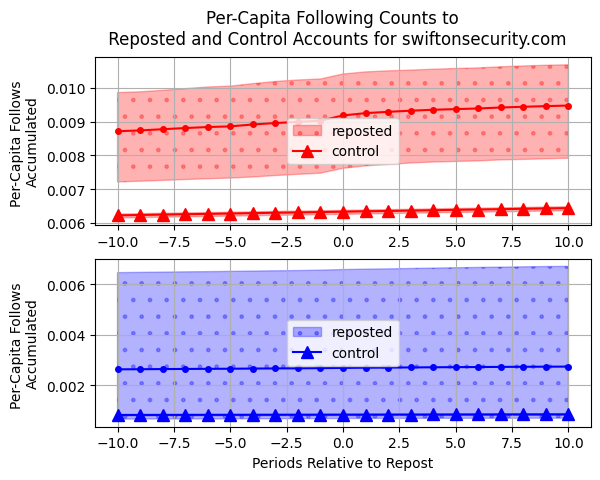

In [44]:
fig, ax = plt.subplots(2, 1)
plot_cis_and_means(df, ax[0], denom=DENOM_FOL)
print('plz')
plot_cis_and_means(df, ax[1], denom=DENOM_NON, colname='tot_non_fol', color='blue')
ax[0].legend()
ax[0].grid()
ax[0].set_ylabel('Per-Capita Follows \nAccumulated')
ax[1].legend()
ax[1].grid()
ax[1].set_ylabel('Per-Capita Follows \nAccumulated')
ax[1].set_xlabel('Periods Relative to Repost')
plt.suptitle(f'Per-Capita Following Counts to \n Reposted and Control Accounts for {HANDLE}')
plt.savefig(f'{FILEPATH}/plots/{HANDLE}_panel_trends.png')